=== BÁO CÁO CHỈ SỐ SỨC KHỎE KHO HÀNG THEO NĂM ===
      Turnover Ratio  Days on Hand (DIO)  Fill Rate (%)
year                                                   
2012            1.54              236.62          95.38
2013            2.55              142.88          95.79
2014            1.94              187.89          95.99
2015            1.61              227.02          95.99
2016            1.43              254.63          96.04
2017            1.24              294.45          96.04
2018            1.06              344.49          96.27
2019            0.67              543.32          96.43
2020            0.56              654.39          96.56
2021            0.60              608.47          96.19
2022            0.69              529.01          96.35




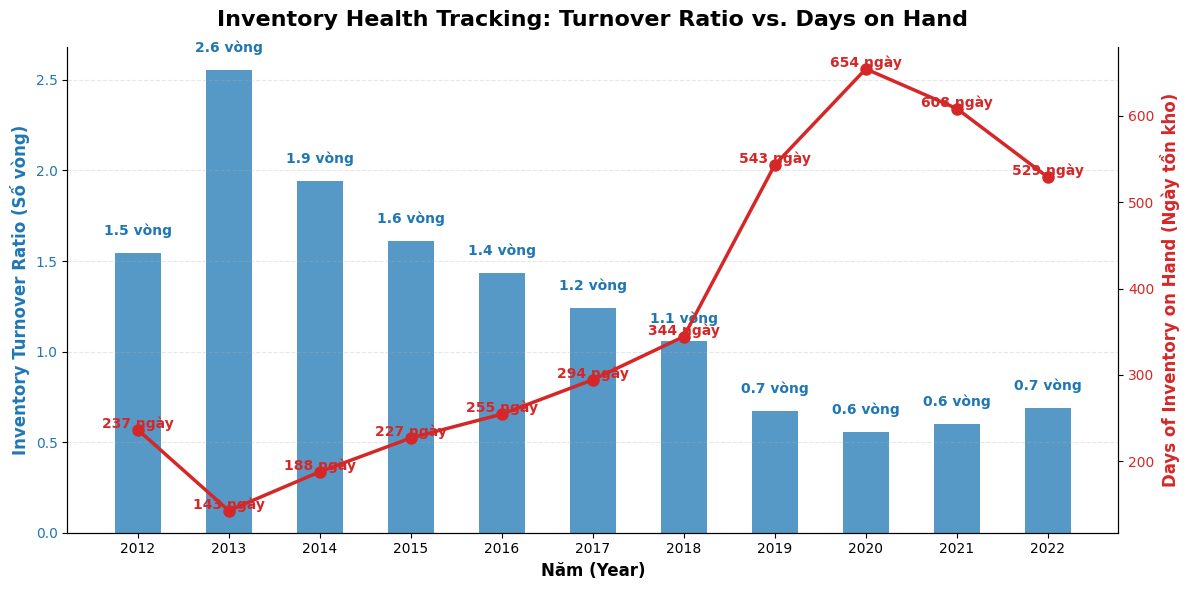

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Đọc dữ liệu
BASE_DATA = "data/"
inventory = pd.read_csv(BASE_DATA + 'inventory.csv')
products = pd.read_csv(BASE_DATA + 'products.csv')

# 2. Bổ sung giá vốn (COGS) vào chuỗi dữ liệu tồn kho để quy đổi Quy mô ra Tiền Tệ ($)
df = inventory.merge(products[['product_id', 'cogs']], on='product_id', how='left')

# Tính COGS cho tổng lượng hàng đã bán và Giá trị hàng tồn kho đọng vốn (Inventory Value)
df['cogs_sold'] = df['units_sold'] * df['cogs']
df['inventory_value'] = df['stock_on_hand'] * df['cogs']

# 3. Gom nhóm theo Năm để theo dõi diễn biến Inventory Health một cách dài hạn
# a. Tính tổng giá vốn hàng bán (Total COGS) của cả năm
total_cogs_yearly = df.groupby('year')['cogs_sold'].sum()

# b. Tính Giá trị tồn kho trung bình (Average Inventory)
# Thu thập Tổng vốn tồn đọng theo từng đợt lấy mẫu kho (snapshot_date), sau đó tính trung bình các lần lấy mẫu trong năm
inventory_snapshots = df.groupby(['year', 'snapshot_date'])['inventory_value'].sum().reset_index()
avg_inv_yearly = inventory_snapshots.groupby('year')['inventory_value'].mean()

# Tạo bảng Báo cáo nháp
kpi_df = pd.DataFrame({
    'Total COGS ($)': total_cogs_yearly,
    'Avg Inventory ($)': avg_inv_yearly
})

# ==========================================
# CÁC CHỈ SỐ KPI LOGISTIC CHÍNH THỨC
# ==========================================

# KPI 1: Inventory turnover ratio = COGS / Average Inventory
kpi_df['Turnover Ratio'] = kpi_df['Total COGS ($)'] / kpi_df['Avg Inventory ($)']

# KPI 2: Days of inventory on hand (DIO) = 365 / Turnover Ratio
kpi_df['Days on Hand (DIO)'] = 365 / kpi_df['Turnover Ratio']

# KPI 3: Fill rate (Tỷ lệ lấy hàng mượt mà từ kho sẵn có thành công)
# Lấy file hiện tại đã có cột fill_rate nguyên gốc, nên chúng ta tính trung bình trong năm
kpi_df['Fill Rate (%)'] = df.groupby('year')['fill_rate'].mean() * 100

# Format bảng hiển thị và làm tròn
kpi_df_display = kpi_df[['Turnover Ratio', 'Days on Hand (DIO)', 'Fill Rate (%)']].round(2)
print("=== BÁO CÁO CHỈ SỐ SỨC KHỎE KHO HÀNG THEO NĂM ===")
print(kpi_df_display)
print("\n")

# ==========================================
# GIAO DIỆN HÓA LÊN BIỂU ĐỒ (DASHBOARD)
# ==========================================
fig, ax1 = plt.subplots(figsize=(12, 6))

# Vẽ Turnover Ratio dưới dạng Cột (Khối lượng Tần suất)
bars = ax1.bar(kpi_df.index, kpi_df['Turnover Ratio'], color='#1f77b4', alpha=0.75, width=0.5, label='Turnover Ratio')
ax1.set_xlabel('Năm (Year)', fontweight='bold', fontsize=12)
ax1.set_ylabel('Inventory Turnover Ratio (Số vòng)', color='#1f77b4', fontweight='bold', fontsize=12)
ax1.tick_params(axis='y', labelcolor='#1f77b4')

# Chú thích số liệu lên đỉnh Cột
for bar in bars:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, yval + 0.1, f'{yval:.1f} vòng', ha='center', fontsize=10, fontweight='bold', color='#1f77b4')

# Trục Y thứ 2: Vẽ Ngày tồn kho (DIO) dưới dạng Đường Line cảnh báo đỏ
ax2 = ax1.twinx()
line = ax2.plot(kpi_df.index, kpi_df['Days on Hand (DIO)'], color='#d62728', marker='o', markersize=8, linewidth=2.5, label='Days on Hand (DIO)')
ax2.set_ylabel('Days of Inventory on Hand (Ngày tồn kho)', color='#d62728', fontweight='bold', fontsize=12)
ax2.tick_params(axis='y', labelcolor='#d62728')

# Chú thích số ngày vào từng điểm rơi của đường Line
for i, v in zip(kpi_df.index, kpi_df['Days on Hand (DIO)']):
    ax2.text(i, v + 2, f'{v:.0f} ngày', ha='center', fontsize=10, fontweight='bold', color='#d62728')

plt.title('Inventory Health Tracking: Turnover Ratio vs. Days on Hand', fontsize=16, fontweight='bold', pad=15)

# Fix cho trục X không hiển thị số lẻ (chỉ in năm chẵn 2018, 2019...)
ax1.set_xticks(kpi_df.index)

# Tối ưu lưới đứt nền cho thoáng
ax1.grid(axis='y', linestyle='--', alpha=0.3)

# Tắt viền trên cùng
ax1.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)

plt.tight_layout()
plt.show()


In [4]:
import pandas as pd
import numpy as np

# 1. Đọc tệp dữ liệu cấp cao (đã tổng hợp sẵn)
BASE_DATA = "data/"
sales = pd.read_csv(BASE_DATA + 'sales.csv')

# 2. Xử lý thời gian để gom cụm theo Năm
sales['Date'] = pd.to_datetime(sales['Date'])
sales['year'] = sales['Date'].dt.year

# 3. Tính Tổng Doanh thu và Giá vốn theo từng năm
financial_yearly = sales.groupby('year').agg(
    Revenue=('Revenue', 'sum'),
    COGS=('COGS', 'sum')
).reset_index()

# 4. Tính Gross Profit và Gross Margin (%)
financial_yearly['Gross_Profit'] = financial_yearly['Revenue'] - financial_yearly['COGS']
financial_yearly['Gross_Margin (%)'] = (financial_yearly['Gross_Profit'] / financial_yearly['Revenue']) * 100

print("--- Bảng kết quả Gross Margin hàng năm ---")
print(financial_yearly)

# 5. Tính Revenue CAGR
# Sắp xếp theo năm để đảm bảo thứ tự
financial_yearly = financial_yearly.sort_values('year')

# Lấy giá trị đầu và cuối
beginning_revenue = financial_yearly['Revenue'].iloc[0]
ending_revenue = financial_yearly['Revenue'].iloc[-1]

# Tính số năm (n)
start_year = financial_yearly['year'].iloc[0]
end_year = financial_yearly['year'].iloc[-1]
n_years = end_year - start_year

if n_years > 0:
    revenue_cagr = (ending_revenue / beginning_revenue) ** (1 / n_years) - 1
    print(f"\n--- Chỉ số CAGR ---")
    print(f"Giai đoạn: {start_year} - {end_year} ({n_years} năm)")
    print(f"Revenue CAGR: {revenue_cagr:.2%}")
else:
    print("\nKhông đủ dữ liệu thời gian để tính CAGR (cần ít nhất 2 năm).")

--- Bảng kết quả Gross Margin hàng năm ---
    year       Revenue          COGS  Gross_Profit  Gross_Margin (%)
0   2012  7.414977e+08  5.874619e+08  1.540358e+08         20.773606
1   2013  1.657169e+09  1.465980e+09  1.911893e+08         11.537101
2   2014  1.871846e+09  1.574607e+09  2.972384e+08         15.879428
3   2015  1.889934e+09  1.665442e+09  2.244920e+08         11.878300
4   2016  2.104641e+09  1.780559e+09  3.240813e+08         15.398414
5   2017  1.911164e+09  1.694386e+09  2.167785e+08         11.342747
6   2018  1.850122e+09  1.542176e+09  3.079467e+08         16.644665
7   2019  1.136801e+09  1.005203e+09  1.315986e+08         11.576213
8   2020  1.054512e+09  8.860851e+08  1.684271e+08         15.972036
9   2021  1.043040e+09  9.411301e+08  1.019097e+08          9.770451
10  2022  1.169749e+09  1.020420e+09  1.493287e+08         12.765874

--- Chỉ số CAGR ---
Giai đoạn: 2012 - 2022 (10 năm)
Revenue CAGR: 4.66%


In [8]:
import pandas as pd
import numpy as np

# 1. Đọc tệp dữ liệu cấp cao (đã tổng hợp sẵn)
BASE_DATA = "data/"
sales = pd.read_csv(BASE_DATA + 'sales.csv')

# 2. Xử lý thời gian để gom cụm theo Năm
sales['Date'] = pd.to_datetime(sales['Date'])
sales['year'] = sales['Date'].dt.year

# 3. Tính Tổng Doanh thu và Giá vốn theo từng năm
financial_yearly = sales.groupby('year').agg(
    Revenue=('Revenue', 'sum'),
    COGS=('COGS', 'sum')
).reset_index()

financial_yearly['Gross_Margin'] = (
    (financial_yearly['Revenue'] - financial_yearly['COGS']) 
    / financial_yearly['Revenue']
)   

financial_yearly = financial_yearly.sort_values('year')

start_revenue = financial_yearly['Revenue'].iloc[0]
end_revenue = financial_yearly['Revenue'].iloc[-1]
num_years = financial_yearly['year'].iloc[-1] - financial_yearly['year'].iloc[0]

cagr = (end_revenue / start_revenue) ** (1 / num_years) - 1

print(financial_yearly['Gross_Margin']*100)
print("Revenue CAGR:", cagr*100)

0     20.773606
1     11.537101
2     15.879428
3     11.878300
4     15.398414
5     11.342747
6     16.644665
7     11.576213
8     15.972036
9      9.770451
10    12.765874
Name: Gross_Margin, dtype: float64
Revenue CAGR: 4.6642289449912555


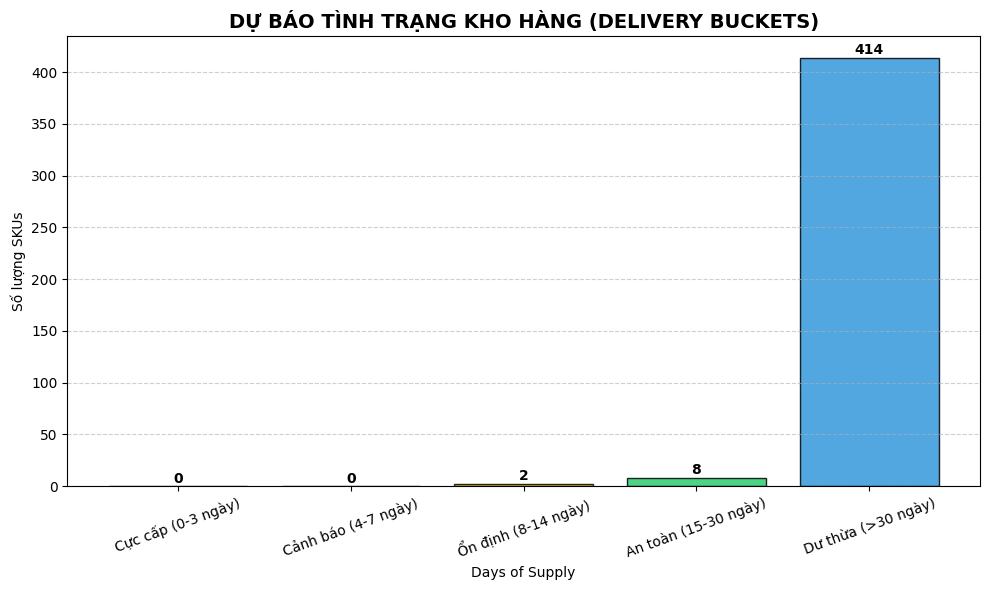

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Đọc dữ liệu
BASE_DATA = "data/"
inventory = pd.read_csv(BASE_DATA + 'inventory.csv')

inventory['split_segment'] = inventory.apply(
    lambda x: f"Activewear - {x['category']}" if x['segment'] == 'Activewear' else x['segment'], 
    axis=1
)
# 2. Lấy snapshot mới nhất
inventory['snapshot_date'] = pd.to_datetime(inventory['snapshot_date'])
latest_date = inventory['snapshot_date'].max()

current_inv = inventory[inventory['snapshot_date'] == latest_date].copy()

# 3. Tính toán tồn kho & velocity (FIX: dùng current_inv, không dùng inventory)
current_inv['stock_level'] = current_inv['stock_on_hand']
current_inv['daily_sales_velocity'] = current_inv['units_sold'] / 30

# 4. Tính Days of Supply (FIX: xử lý chia cho 0 đúng cách)
current_inv['days_of_supply'] = np.where(
    current_inv['daily_sales_velocity'] == 0,
    np.inf,
    current_inv['stock_level'] / current_inv['daily_sales_velocity']
)

# 5. Định nghĩa Delivery Buckets
bins = [0, 3, 7, 14, 30, float('inf')]
labels = [
    'Cực cấp (0-3 ngày)',
    'Cảnh báo (4-7 ngày)',
    'Ổn định (8-14 ngày)',
    'An toàn (15-30 ngày)',
    'Dư thừa (>30 ngày)'
]

current_inv['delivery_bucket'] = pd.cut(
    current_inv['days_of_supply'],
    bins=bins,
    labels=labels,
    right=True,
    include_lowest=True
)

# 6. Tổng hợp dữ liệu theo cả Bucket và Segment
# Chúng ta đếm số lượng SKU cho mỗi cặp (Bucket, Segment)
bucket_segment_counts = (
    current_inv.groupby(['delivery_bucket', 'split_segment'])
    .size()
    .unstack(fill_value=0) # Chuyển Segment thành các cột để vẽ group bar
)

# Đảm bảo thứ tự các Bucket đúng như định nghĩa ban đầu
bucket_segment_counts = bucket_segment_counts.reindex(labels)

# 7. Vẽ biểu đồ Grouped Bar Chart
# Sử dụng trực tiếp phương thức plot của pandas để vẽ group bar dễ dàng hơn
ax = bucket_segment_counts.plot(
    kind='bar', 
    figsize=(12, 7), 
    width=0.8, 
    edgecolor='black',
    alpha=0.85,
    colormap='viridis' # Hoặc chọn bảng màu khác như 'tab10', 'Set3'
)

# Hiển thị số lượng trên đầu mỗi cột
for p in ax.patches:
    y_value = p.get_height()
    if y_value > 0: # Chỉ hiện số nếu giá trị lớn hơn 0
        ax.annotate(
            f'{int(y_value)}', 
            (p.get_x() + p.get_width() / 2., y_value), 
            ha='center', va='center', 
            xytext=(0, 7), 
            textcoords='offset points',
            fontsize=9,
            fontweight='bold'
        )

# Tinh chỉnh giao diện
plt.title('DỰ BÁO TÌNH TRẠNG KHO THEO PHÂN KHÚC (DELIVERY BUCKETS)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Khoảng thời gian dự kiến hết hàng', fontsize=11)
plt.ylabel('Số lượng SKUs', fontsize=11)
plt.xticks(rotation=15) # Xoay nhẹ nhãn trục X để dễ đọc
plt.legend(title="Phân khúc (Segment)", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()